Import Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import os

sns.set_theme(style="whitegrid")

Load Data

In [ ]:
def extract_zip(zip_path, extract_path="/content/data"):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    return extract_path

def load_csv(folder_path):
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            print(f"Loading file: {file}")
            return pd.read_csv(os.path.join(folder_path, file))

# Extract & Load
data_path = extract_zip("/content/archive.zip")
df = load_csv(data_path)

Loading file: Telco-Customer-Churn.csv


Data Cleaning

In [ ]:
def clean_data(df):
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df = df.dropna()
    df = df.drop(columns=['customerID'])
    return df

df = clean_data(df)

# EDA

Churn Distribution

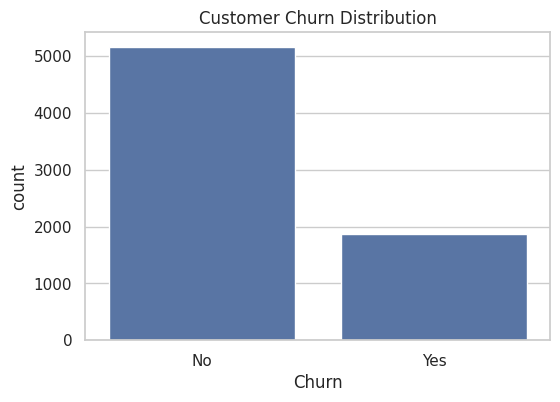


Insight:
Majority of customers are retained, but churn proportion is still significant.
This indicates churn is a critical business issue.



In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

print("""
Insight:
Majority of customers are retained, but churn proportion is still significant.
This indicates churn is a critical business issue.
""")

Tenure vs Churn

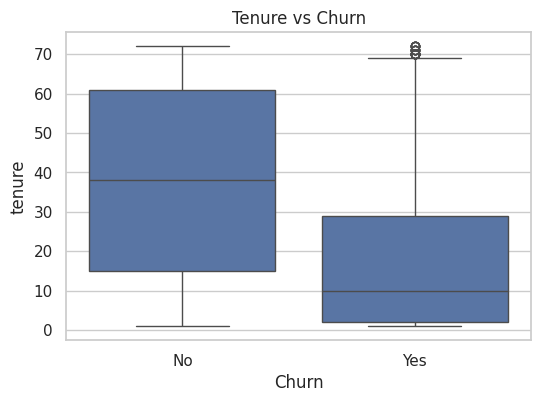


Insight:
Customers with shorter tenure are significantly more likely to churn.
This suggests dissatisfaction happens early in the customer lifecycle.



In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

print("""
Insight:
Customers with shorter tenure are significantly more likely to churn.
This suggests dissatisfaction happens early in the customer lifecycle.
""")

Monthly Charges vs Churn

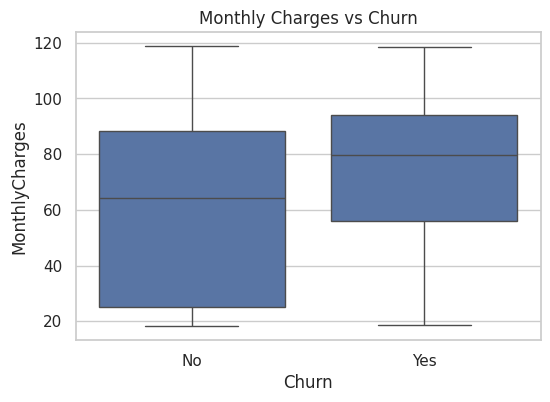


Insight:
Higher monthly charges are associated with higher churn rates.
Customers may perceive pricing as too expensive.



In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

print("""
Insight:
Higher monthly charges are associated with higher churn rates.
Customers may perceive pricing as too expensive.
""")

Contract vs Churn

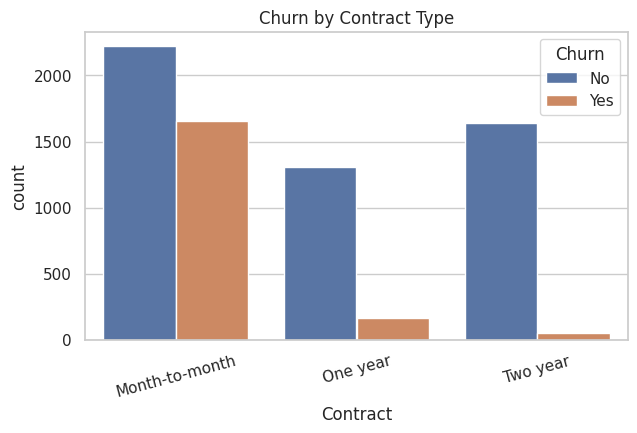


Insight:
Month-to-month contracts show the highest churn.
Long-term contracts help retain customers.



In [32]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

print("""
Insight:
Month-to-month contracts show the highest churn.
Long-term contracts help retain customers.
""")

Tech Support vs Churn

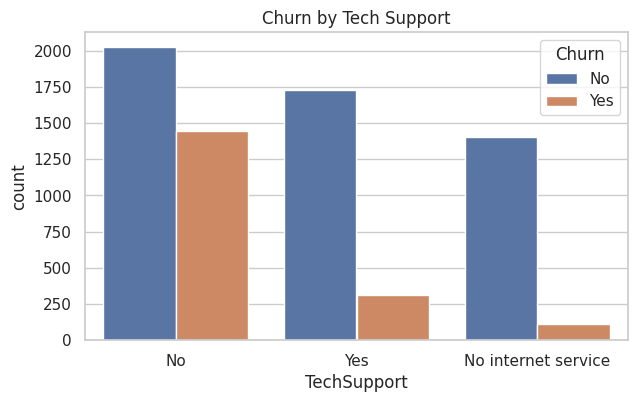


Insight:
Customers without tech support are more likely to churn.
Support service plays a key role in retention.



In [33]:
plt.figure(figsize=(7,4))
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title("Churn by Tech Support")
plt.show()

print("""
Insight:
Customers without tech support are more likely to churn.
Support service plays a key role in retention.
""")

Internet Service vs Churn

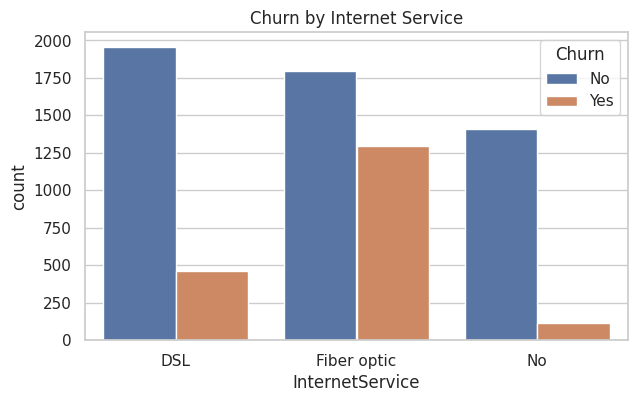


Insight:
Fiber optic users show higher churn compared to DSL users.
Possible issue: service quality or pricing expectations.



In [34]:
plt.figure(figsize=(7,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()

print("""
Insight:
Fiber optic users show higher churn compared to DSL users.
Possible issue: service quality or pricing expectations.
""")

Churn Rate per Contract

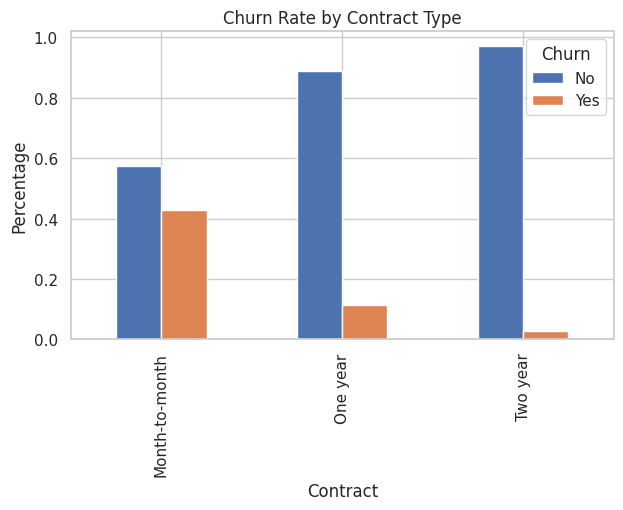


Insight:
Month-to-month contracts dominate churn percentage.
This segment should be prioritized for retention strategies.



In [35]:
churn_rate = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()

churn_rate.plot(kind='bar', figsize=(7,4))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage")
plt.show()

print("""
Insight:
Month-to-month contracts dominate churn percentage.
This segment should be prioritized for retention strategies.
""")

Business Insights

In [36]:
print("""
Key Findings:

1. Contract Type
- Month-to-month customers have the highest churn
→ Strategy: Offer discounts for long-term contracts

2. Tenure
- New customers churn more frequently
→ Strategy: Improve onboarding experience

3. Pricing
- High monthly charges increase churn
→ Strategy: Review pricing or provide better value

4. Support Services
- Lack of tech support increases churn
→ Strategy: Enhance customer support access

5. Internet Service
- Fiber optic users churn more
→ Strategy: Evaluate service quality or pricing
""")


Key Findings:

1. Contract Type
- Month-to-month customers have the highest churn
→ Strategy: Offer discounts for long-term contracts

2. Tenure
- New customers churn more frequently
→ Strategy: Improve onboarding experience

3. Pricing
- High monthly charges increase churn
→ Strategy: Review pricing or provide better value

4. Support Services
- Lack of tech support increases churn
→ Strategy: Enhance customer support access

5. Internet Service
- Fiber optic users churn more
→ Strategy: Evaluate service quality or pricing

